# **C08 - Trayectorias del precio y valuación de una opción asiática**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez
**Carrera:** Ingeniería Financiera
**Institución:** ITESO — Universidad Jesuita de Guadalajara
**Semestre:** 5° — Simulación de Procesos Financieros
**Fecha de realización:** 14 de septiembre de 2026

---

**Ejercicio:** completar el trabajo hecho en clase simulando 50 trayectorias del precio con una envolvente del intervalo de confianza al 95% y una línea horizontal en el strike, y después 1,000 trayectorias sobre las cuales calcular el promedio de cada camino, graficar los payoffs de la opción europea y de la asiática y comparar el precio de ambos contratos.

Los notebooks anteriores simularon el precio del activo únicamente en la fecha de vencimiento, ya que la call europea sólo mira ese punto y el resto del camino no altera su pago. Aquí se conserva la trayectoria completa día con día, y esa decisión no es cosmética: al promediar los 253 precios de cada camino aparece un contrato distinto, la opción asiática, cuyo subyacente es un promedio y no un precio, de modo que el mismo conjunto de simulaciones permite valuar dos opciones que responden de manera muy distinta al mismo riesgo.

## Índice de contenidos

1. Sección 1 — Generador del precio y parámetros
2. Sección 2 — Simulación de 50 trayectorias y envolvente al 95%
3. Sección 3 — Simulación de 1,000 trayectorias
4. Sección 4 — Distribución de los payoffs
5. Sección 5 — Precio de las opciones y comparación
6. Sección 6 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(14)

## 1. Generador del precio y parámetros

El precio del activo sigue un movimiento browniano geométrico, de manera que el valor al cabo de un intervalo $\Delta t$ se obtiene multiplicando el valor previo por la exponencial de un incremento con deriva $(r - \sigma^2/2)\,\Delta t$ y desviación $\sigma\sqrt{\Delta t}$.

$$S_{t+\Delta t} = S_t \exp\left[\left(r - \frac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\, Z\right], \qquad Z \sim N(0,1)$$

La función recibe un solo paso y devuelve un solo precio, así que la trayectoria se construye encadenando llamadas y tomando cada resultado como punto de partida de la siguiente. El horizonte es de un año dividido en 252 días hábiles, con $\Delta t = 1/252$, precio inicial de 100 pesos, tasa libre de riesgo de 5%, volatilidad de 20% y strike de 110 pesos, es decir, una call fuera del dinero.

La semilla queda fija en 14 para que las cifras citadas en las interpretaciones se reproduzcan exactamente al volver a correr el notebook.

In [2]:
def s(r, sigma, T, S0):
    return S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * np.random.normal(0, 1))

## 2. Simulación de 50 trayectorias y envolvente al 95%

Las primeras 50 trayectorias se grafican sin ningún tratamiento, únicamente para observar la dispersión que el proceso genera a lo largo del año.

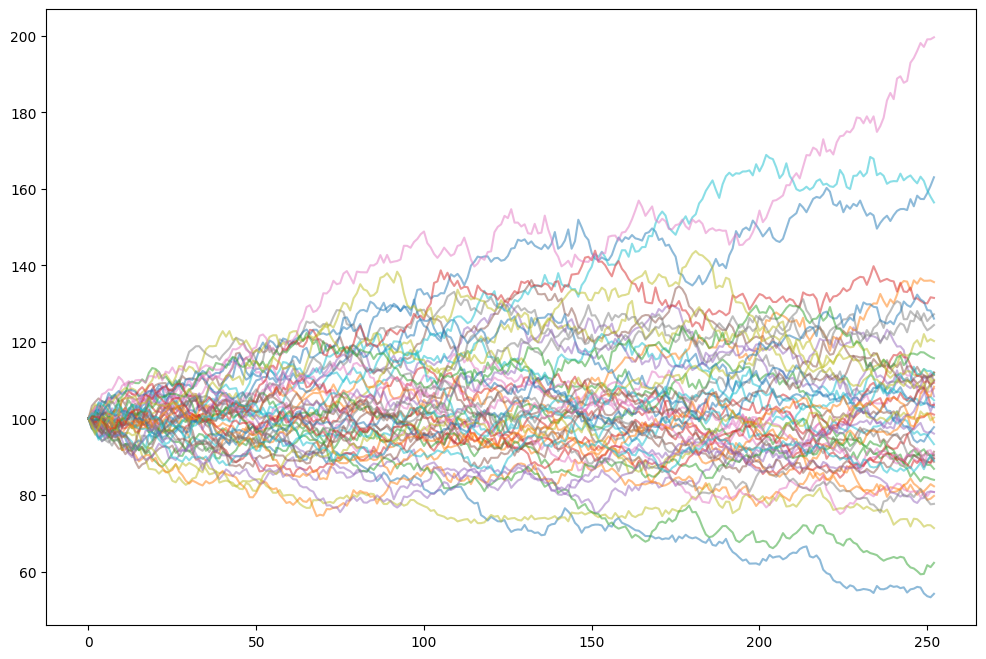

In [3]:
trayectorias = []
for i in range(50):
    trayectoria = [100]
    dt = 1/252
    T = 0
    for j in range(252):
        S0 = s(0.05, 0.20, dt, trayectoria[-1])
        trayectoria.append(S0)
    trayectorias.append(trayectoria)

trayectorias = np.array(trayectorias)

plt.figure(figsize=(12, 8))
for i in range(trayectorias.shape[0]):
    plt.plot(trayectorias[i], alpha=0.5)
plt.show()

Las cincuenta trayectorias parten del mismo punto y se abren en forma de abanico conforme avanza el año, con precios finales que van de 54 a 200 pesos, es decir, un rango de casi cuatro a uno entre el peor y el mejor escenario a partir de parámetros idénticos. Esa apertura es la firma del proceso, ya que la desviación del logaritmo del precio crece con $\sqrt{t}$ y por ello la incertidumbre no se acumula de forma lineal sino que se ensancha con rapidez al principio y más lentamente después.

Sobre el mismo conjunto se dibuja ahora la envolvente del intervalo de confianza al 95%, construida con los percentiles 2.5 y 97.5 calculados día con día, junto con una línea horizontal en el precio inicial y otra en el strike de 110 pesos.

Conviene precisar que se trata de un intervalo empírico y no de una banda teórica, ya que los percentiles se estiman de la propia muestra y con cincuenta trayectorias cada extremo queda determinado por poco más de una observación, lo cual explica que las líneas punteadas se vean quebradas en lugar de suaves.

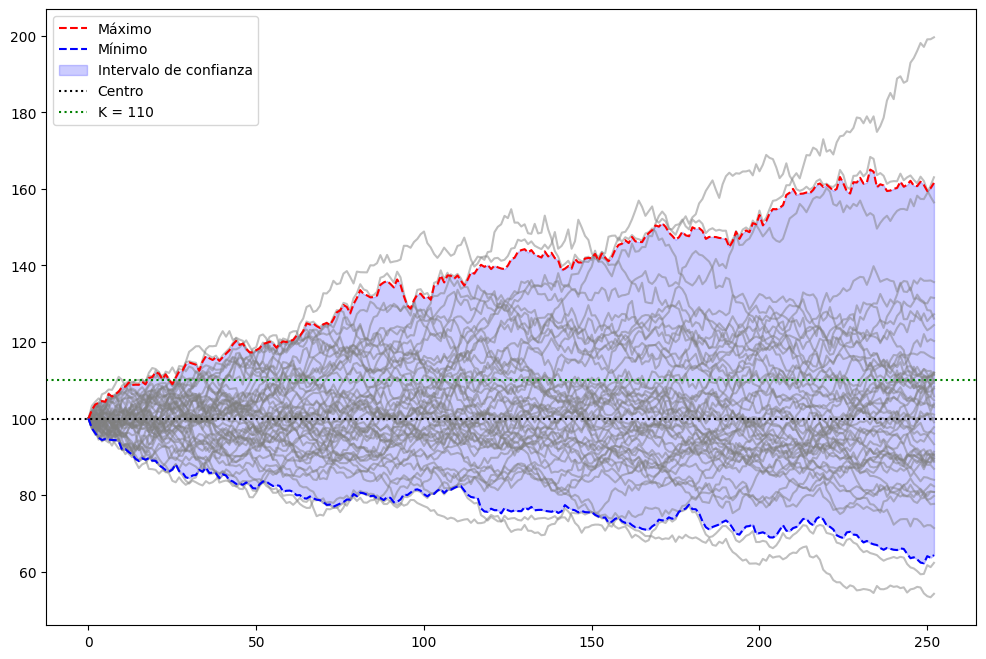

In [4]:
plt.figure(figsize=(12, 8))
for i in range(trayectorias.shape[0]):
    plt.plot(trayectorias[i], alpha=0.5, color='gray')

max_values, min_values = np.percentile(trayectorias, [97.5, 2.5], axis=0)
centro = np.mean(trayectorias, axis=0)

plt.plot(max_values, color='red', linestyle='--', label='Máximo')
plt.plot(min_values, color='blue', linestyle='--', label='Mínimo')
plt.fill_between(range(len(max_values)), max_values, min_values, color='blue', alpha=0.2, label='Intervalo de confianza')
K = 110
plt.axhline(centro[0], color='black', linestyle=':', label='Centro')
plt.axhline(K, color='green', linestyle=':', label='K = 110')
plt.legend()
plt.show()

La envolvente termina abarcando de 64 a 162 pesos, casi cien pesos de amplitud alrededor de un precio inicial de 100, y su forma confirma lo que el gráfico anterior sugería, pues crece con rapidez en los primeros meses y después se ensancha cada vez más despacio.

La línea del strike corta la banda superior alrededor del día 18 y a partir de ahí permanece dentro del intervalo, lo cual significa que desde las primeras semanas hay escenarios en los que la opción ya estaría dentro del dinero. Lo relevante para la valuación, sin embargo, no es cruzar el strike en el camino sino terminar por encima de él, y en ese sentido dieciséis de las cincuenta trayectorias, un 32%, cierran el año arriba de 110 pesos.

La banda tampoco es simétrica respecto del precio inicial, ya que se extiende unos 62 pesos hacia arriba y sólo unos 36 hacia abajo, y esa asimetría no es un artefacto de la muestra sino la consecuencia directa de trabajar con un proceso lognormal, en el que el precio no puede volverse negativo y en cambio el espacio disponible hacia arriba no tiene límite.

## 3. Simulación de 1,000 trayectorias

El ejercicio se repite con mil trayectorias, y de cada una se guardan dos cifras: el precio al vencimiento, que es el subyacente de la call europea, y el promedio de los 253 precios del camino, que es el subyacente de la call asiática. El histograma superpone ambas distribuciones para comparar su forma.

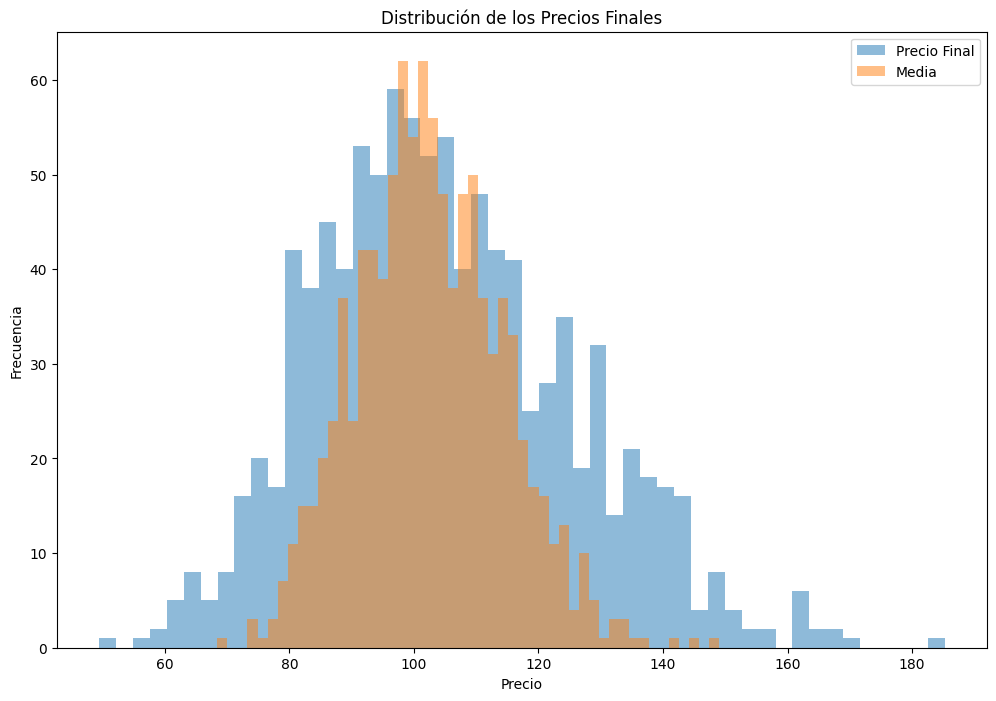

In [5]:
trayectorias_2 = []
Media = []
Precio_Final = []
for i in range(1000):
    trayectoria = [100]
    dt = 1/252
    T = 0
    for j in range(252):
        S0 = s(0.05, 0.20, dt, trayectoria[-1])
        trayectoria.append(S0)
    trayectorias_2.append(trayectoria)
    Media.append(np.mean(trayectoria))
    Precio_Final.append(trayectoria[-1])

plt.figure(figsize=(12, 8))
plt.hist(Precio_Final, bins=50, alpha=0.5, label='Precio Final')
plt.hist(Media, bins=50, alpha=0.5, label='Media')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.title('Distribución de los Precios Finales')
plt.legend()
plt.show()

Las dos distribuciones comparten el mismo centro pero no la misma anchura, y en esa diferencia está el resultado que gobierna todo lo que sigue. El precio final se reparte sobre un rango que va de 49 a 185 pesos, mientras que el promedio del camino se concentra entre 68 y 149, poco más de la mitad de amplitud, porque promediar 253 observaciones correlacionadas cancela buena parte de las desviaciones diarias y deja un estadístico mucho más estable que el punto final.

Ambas conservan la asimetría hacia la derecha propia del proceso lognormal, con una cola superior más larga que la inferior, aunque el promedio la exhibe de forma más discreta por la misma razón, ya que al suavizar la trayectoria también recorta los escenarios extremos que producen esa cola.

## 4. Distribución de los payoffs

El payoff de cada contrato se obtiene aplicando la función de pago a su respectivo subyacente, de modo que la europea paga $\max(S_T - K,\, 0)$ y la asiática $\max(\bar{S} - K,\, 0)$, donde $\bar{S}$ es el promedio de la trayectoria. El histograma superpone ambos pagos y el conteo indica en qué proporción de las mil simulaciones cada contrato termina con valor positivo.

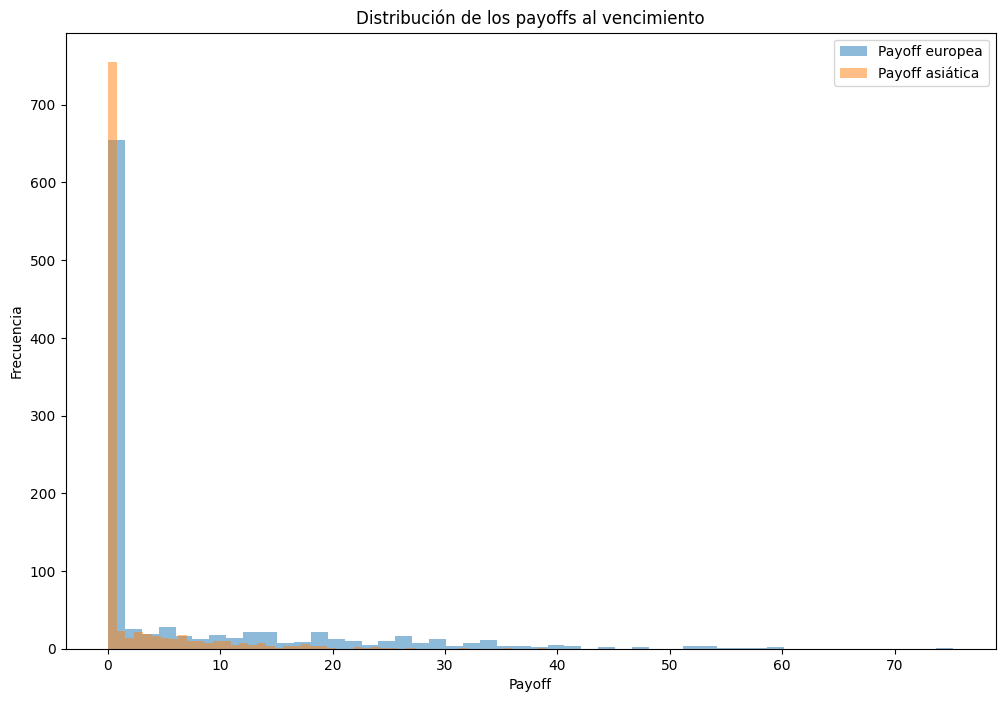

Trayectorias con payoff positivo — europea: 37.8% | asiática: 25.5%


In [6]:
Precio_Final = np.array(Precio_Final)
Media = np.array(Media)

payoff_europea = np.maximum(Precio_Final - K, 0)
payoff_asiatica = np.maximum(Media - K, 0)

plt.figure(figsize=(12, 8))
plt.hist(payoff_europea, bins=50, alpha=0.5, label='Payoff europea')
plt.hist(payoff_asiatica, bins=50, alpha=0.5, label='Payoff asiática')
plt.xlabel('Payoff')
plt.ylabel('Frecuencia')
plt.title('Distribución de los payoffs al vencimiento')
plt.legend()
plt.show()

print(f"Trayectorias con payoff positivo — europea: {np.mean(payoff_europea > 0):.1%} | asiática: {np.mean(payoff_asiatica > 0):.1%}")

Los dos histogramas están dominados por la barra en cero, y esa concentración no es un defecto del gráfico sino la característica esencial del pago de una opción, ya que el contrato sencillamente no se ejerce cuando el subyacente termina por debajo del strike. La europea paga algo en 37.8% de las simulaciones y la asiática en 25.5%, de manera que casi dos de cada tres trayectorias dejan sin valor a la primera y tres de cada cuatro a la segunda.

La distancia entre ambas proporciones tiene un origen preciso, pues el promedio del camino es un estadístico más estrecho que el precio final y, con el strike situado por encima del precio inicial, esa menor dispersión juega en contra del tenedor al reducir la probabilidad de alcanzar la región donde el contrato paga. La cola también se acorta, ya que el pago máximo observado llega a 75 pesos en la europea y apenas a 39 en la asiática.

Conviene subrayar que la misma propiedad que aquí perjudica a la asiática es la que la protege en el escenario contrario, dado que un promedio es difícil de mover y por ello el contrato resulta mucho menos vulnerable a una manipulación del precio en la fecha de vencimiento, que es justamente la razón por la cual este tipo de opción se utiliza en mercados poco líquidos.

## 5. Precio de las opciones y comparación

El precio de cada contrato es el valor presente del pago esperado, así que se promedian los mil payoffs y el resultado se descuenta un año a la tasa libre de riesgo. En seguida se calcula la desviación estándar de los payoffs de cada contrato, que mide qué tan disperso queda el pago alrededor de ese promedio.

In [7]:
mean_payoff_europea = np.mean(payoff_europea)
mean_payoff_asiatica = np.mean(payoff_asiatica)

VR_payoff_europea = np.exp(-0.05) * mean_payoff_europea
VR_payoff_asiatica = np.exp(-0.05) * mean_payoff_asiatica

print(f"Valor presente de la opción europea: {VR_payoff_europea}")
print(f"Valor presente de la opción asiática: {VR_payoff_asiatica}")

Valor presente de la opción europea: 5.925644247554373
Valor presente de la opción asiática: 1.8653738174270444


In [8]:
Volatilidad_europea = np.std(payoff_europea)
Volatilidad_asiatica = np.std(payoff_asiatica)

print(f"Volatilidad de la opción europea: {Volatilidad_europea}")
print(f"Volatilidad de la opción asiática: {Volatilidad_asiatica}")

Volatilidad de la opción europea: 11.455999419946641
Volatilidad de la opción asiática: 4.671696764651007


La call europea vale 5.9256 pesos y la asiática 1.8654, de modo que la segunda cuesta 3.18 veces menos que la primera pese a escribirse sobre el mismo activo, con el mismo strike y el mismo horizonte. Toda la diferencia proviene del subyacente elegido, ya que el promedio del camino es una variable más concentrada y, con el strike fuera del dinero, esa concentración se traduce en menos escenarios de ejercicio y en pagos más pequeños cuando el ejercicio llega a ocurrir.

La desviación estándar de los payoffs confirma el mismo hecho desde el lado del riesgo, con 11.4560 en la europea contra 4.6717 en la asiática, es decir, una dispersión 2.45 veces menor. Ahora bien, esa comparación en niveles favorece a la asiática por construcción, dado que también su pago promedio es menor, y al medir cada desviación contra el pago esperado del propio contrato el orden se invierte, pues la de la europea equivale a 1.84 veces su pago medio y la de la asiática a 2.38 veces el suyo.

Esa inversión merece atención porque contradice la lectura ingenua de que la opción asiática es sencillamente una versión más segura de la europea. Lo que ocurre es que la asiática paga en menos ocasiones y por montos menores, así que su valor esperado se sostiene sobre una fracción más pequeña de la muestra y su estimación por simulación resulta proporcionalmente más ruidosa, lo cual obliga a usar más trayectorias para alcanzar la misma precisión relativa.

## 6. Conclusiones

Conservar la trayectoria completa en lugar de sólo el precio final cambia lo que puede valuarse con una misma simulación, ya que los 253 precios de cada camino permiten construir el promedio que sirve de subyacente a la opción asiática, y de ahí salen dos contratos con precios muy distintos, 5.9256 pesos la europea y 1.8654 la asiática, a partir de un único conjunto de mil trayectorias.

La razón de esa brecha de 3.18 veces está en la dispersión del subyacente y no en alguna diferencia del activo, la tasa o el plazo, pues el promedio de 253 observaciones correlacionadas es un estadístico mucho más estable que el punto final, y con el strike fijado 10% arriba del precio inicial esa estabilidad reduce la probabilidad de ejercicio de 37.8% a 25.5% y recorta el pago máximo de 75 a 39 pesos.

El resultado se generaliza en una dirección que conviene dejar explícita, ya que promediar no es una operación neutral sino que favorece o perjudica según dónde esté el strike, de manera que la asiática es más barata mientras la opción esté fuera del dinero y su descuento se reduce conforme el strike se acerca al precio inicial, porque entonces la menor dispersión deja de ser un obstáculo para alcanzar la región de ejercicio.

La medida de riesgo admite dos lecturas opuestas según se normalice o no, dado que en niveles la asiática dispersa 2.45 veces menos que la europea, pero al medir cada desviación contra el pago esperado de su propio contrato la relación pasa de 1.84 a 2.38 veces, con la consecuencia práctica de que estimar el precio de la asiática por simulación exige más trayectorias que estimar el de la europea con la misma precisión relativa.

El principal límite del ejercicio es el tamaño de la muestra, pues mil trayectorias dejan un error de simulación apreciable frente a diferencias de décimas de peso, y la envolvente del segundo apartado lo ilustra con claridad al estimar los percentiles extremos con cincuenta observaciones, lo cual produce bandas quebradas en lugar de suaves. La extensión natural es contrastar el precio de la europea contra la fórmula de Black-Scholes, que existe en forma cerrada y permitiría medir el sesgo del estimador, ejercicio que para la asiática no es posible por la misma vía dado que el promedio aritmético de variables lognormales no es lognormal y el contrato carece de solución cerrada.